# Análise de Risco e Retorno de Setores do Ibovespa

**Autor:** Moisés  
**Data:** Julho 2026  
**Objetivo:** Comparar o desempenho de 5 setores da B3 nos últimos 12 meses, analisando retorno, risco e diversificação.

### Setores analisados
| Setor | Ativo | Ticker |
|-------|-------|--------|
| Financeiro | Itaú | ITUB4 |
| Energia | Petrobras | PETR4 |
| Consumo | Ambev | ABEV3 |
| Commodities | Suzano | SUZB3 |
| Utilities | Cemig | CMIG4 |

### Ferramentas utilizadas
- Python 3.14
- pandas (manipulação de dados)
- matplotlib (visualização)
- yfinance (coleta de dados)
- Jupyter Notebook

## 1. Setup e Importações

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 2. Definição dos Ativos e Coleta de Dados

In [6]:
ativos = {
    'ITUB4.SA': 'Financeiro',
    'PETR4.SA': 'Energia',
    'ABEV3.SA': 'Consumo',
    'SUZB3.SA': 'Commodities',
    'CMIG4.SA': 'Utilities'
}

print("Baixando dados...\n")
dados_brutos = yf.download(
    tickers=list(ativos.keys()),
    period='1y'
)

print(f"\nDados baixados: {dados_brutos.shape[0]} pregões")
print("Todos os ativos OK!") if dados_brutos.shape[1] > 0 else print("Algo deu errado")

Baixando dados...



[*********************100%***********************]  5 of 5 completed


Dados baixados: 250 pregões
Todos os ativos OK!


In [7]:
precos = dados_brutos['Close']
precos.columns = [ativos[ticker] for ticker in precos.columns]

print("Primeiras 5 linhas:")
print(precos.head())

Primeiras 5 linhas:
              Consumo  Utilities  Financeiro    Energia  Commodities
Date                                                                
2025-07-14  12.670704   9.532532   31.036903  29.599276    48.885708
2025-07-15  12.651636   9.496761   31.143620  29.369465    49.423988
2025-07-16  13.042531   9.407340   31.294800  29.222389    49.443562
2025-07-17  12.832783   9.353684   31.766142  28.928234    49.423988
2025-07-18  12.699306   9.282147   31.188084  28.487003    49.531647


## 3. Validação e Limpeza dos Dados

In [8]:
print("Dados faltantes por setor:")
print(precos.isnull().sum())

print(f"\nPeríodo: {precos.index[0].strftime('%d/%m/%Y')} a {precos.index[-1].strftime('%d/%m/%Y')}")
print(f"Total de pregões: {len(precos)}")

Dados faltantes por setor:
Consumo        0
Utilities      0
Financeiro     0
Energia        0
Commodities    1
dtype: int64

Período: 14/07/2025 a 13/07/2026
Total de pregões: 250


In [9]:
precos = precos.ffill()

print("Dados faltantes depois do tratamento:")
print(precos.isnull().sum())

Dados faltantes depois do tratamento:
Consumo        0
Utilities      0
Financeiro     0
Energia        0
Commodities    0
dtype: int64


In [26]:

# 1. Preços absurdos (zerados ou negativos)
print("1) Preços zerados ou negativos por setor:")
print((precos <= 0).sum())

# 2. Estatísticas básicas pra conferir se os valores fazem sentido
print("\n2) Faixa de preços por setor (R$):")
for setor in precos.columns:
    print(f"  {setor}: mín R${precos[setor].min():.2f} | máx R${precos[setor].max():.2f}")

# 3. Dias úteis entre datas consecutivas (buracos no calendário)
dias_entre_pregoes = precos.index.to_series().diff().dt.days
buracos = dias_entre_pregoes[dias_entre_pregoes > 4]
print(f"\n3) Buracos maiores que 4 dias (feriados prolongados): {len(buracos)}")
if len(buracos) > 0:
    for data, dias in buracos.items():
        print(f"  {data.strftime('%d/%m/%Y')}: {int(dias)} dias sem pregão")

1) Preços zerados ou negativos por setor:
Consumo        0
Utilities      0
Financeiro     0
Energia        0
Commodities    0
dtype: int64

2) Faixa de preços por setor (R$):
  Consumo: mín R$11.16 | máx R$16.90
  Utilities: mín R$9.16 | máx R$13.28
  Financeiro: mín R$30.65 | máx R$48.43
  Energia: mín R$27.61 | máx R$48.52
  Commodities: mín R$39.68 | máx R$58.97

3) Buracos maiores que 4 dias (feriados prolongados): 1
  18/02/2026: 5 dias sem pregão


## 4. Cálculo dos Retornos

In [11]:
retornos = precos.pct_change().dropna()

print("Primeiras 5 linhas dos retornos diários (%):")
print((retornos * 100).head().round(2))

Primeiras 5 linhas dos retornos diários (%):
            Consumo  Utilities  Financeiro  Energia  Commodities
Date                                                            
2025-07-15    -0.15      -0.38        0.34    -0.78         1.10
2025-07-16     3.09      -0.94        0.49    -0.50         0.04
2025-07-17    -1.61      -0.57        1.51    -1.01        -0.04
2025-07-18    -1.04      -0.76       -1.82    -1.53         0.22
2025-07-21     0.75       0.96        1.17     0.19         0.77


## 5. Análise Exploratória

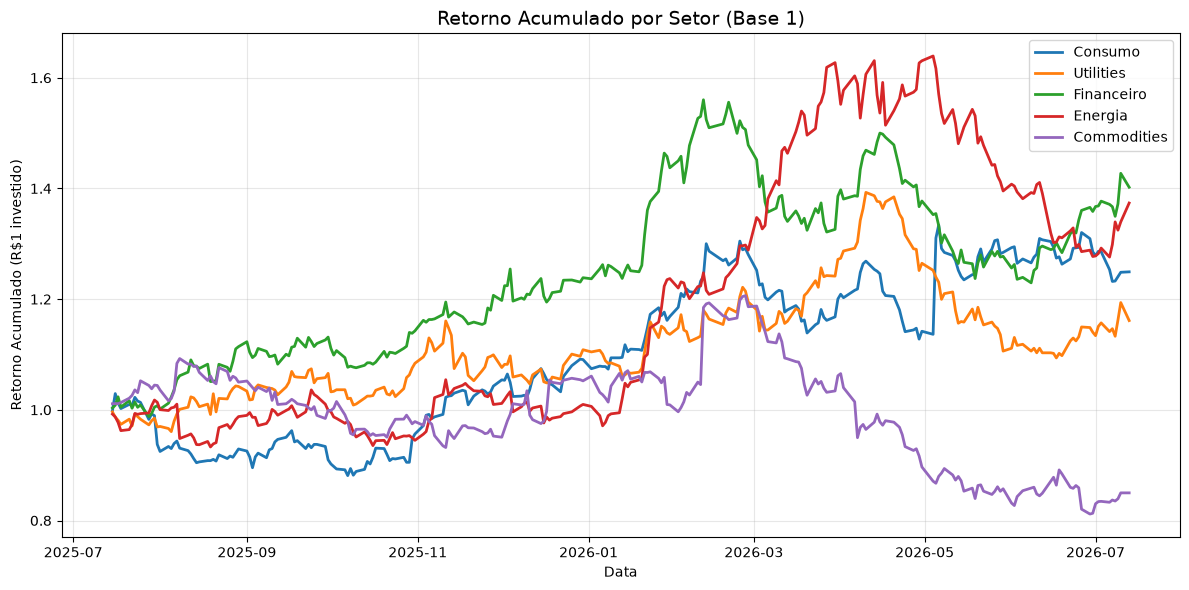

In [12]:
retorno_acumulado = (1 + retornos).cumprod()

plt.figure(figsize=(12, 6))
for setor in retorno_acumulado.columns:
    plt.plot(retorno_acumulado.index, retorno_acumulado[setor], label=setor, linewidth=2)

plt.title('Retorno Acumulado por Setor (Base 1)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado (R$1 investido)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
print("=== RETORNO TOTAL NO PERÍODO ===\n")
for setor in retorno_acumulado.columns:
    retorno_total = (retorno_acumulado[setor].iloc[-1] - 1) * 100
    print(f"  {setor}: {retorno_total:+.2f}%")

=== RETORNO TOTAL NO PERÍODO ===

  Consumo: +24.93%
  Utilities: +16.13%
  Financeiro: +40.22%
  Energia: +37.37%
  Commodities: -15.01%


In [14]:
volatilidade = retornos.std() * (252 ** 0.5) * 100

print("=== VOLATILIDADE ANUALIZADA ===\n")
for setor in volatilidade.index:
    print(f"  {setor}: {volatilidade[setor]:.2f}%")

=== VOLATILIDADE ANUALIZADA ===

  Consumo: 26.06%
  Utilities: 22.82%
  Financeiro: 23.24%
  Energia: 25.16%
  Commodities: 26.79%


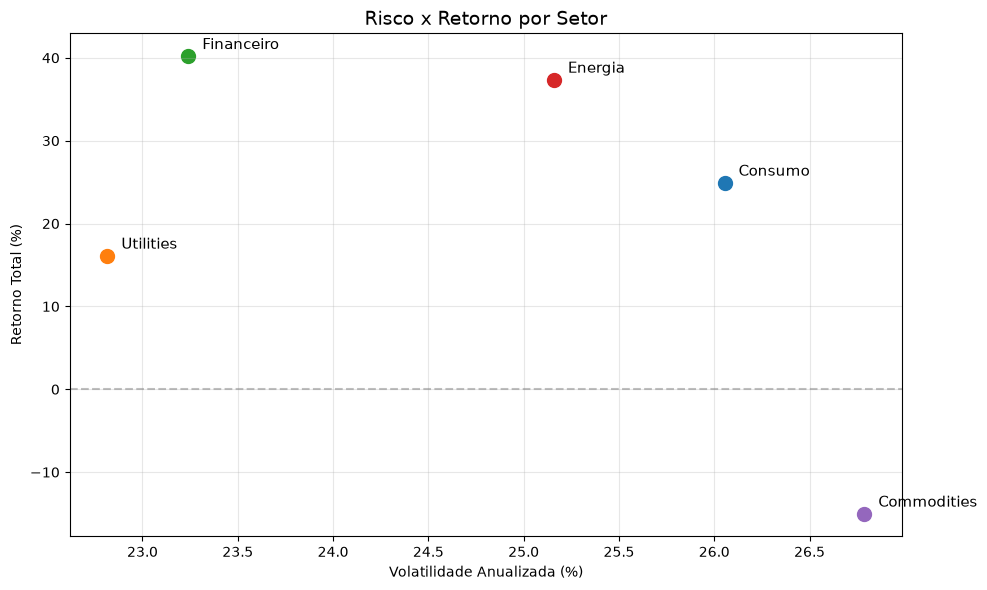

In [15]:
plt.figure(figsize=(10, 6))

retorno_total = (retorno_acumulado.iloc[-1] - 1) * 100

for setor in retorno_total.index:
    plt.scatter(volatilidade[setor], retorno_total[setor], s=100)
    plt.annotate(setor, (volatilidade[setor], retorno_total[setor]),
                 textcoords="offset points", xytext=(10, 5), fontsize=11)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Risco x Retorno por Setor', fontsize=14)
plt.xlabel('Volatilidade Anualizada (%)')
plt.ylabel('Retorno Total (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Indicadores de Performance

In [16]:
taxa_selic = 0.1375
taxa_diaria = (1 + taxa_selic) ** (1/252) - 1

sharpe = (retornos.mean() - taxa_diaria) / retornos.std() * (252 ** 0.5)

print("=== SHARPE RATIO ===\n")
for setor in sharpe.index:
    print(f"  {setor}: {sharpe[setor]:.2f}")

print("\nComo interpretar:")
print("  > 1.0 = Excelente")
print("  0.5 a 1.0 = Bom")
print("  0 a 0.5 = Medíocre")
print("  < 0 = Perdeu pro CDI")

=== SHARPE RATIO ===

  Consumo: 0.50
  Utilities: 0.21
  Financeiro: 1.03
  Energia: 0.89
  Commodities: -0.96

Como interpretar:
  > 1.0 = Excelente
  0.5 a 1.0 = Bom
  0 a 0.5 = Medíocre
  < 0 = Perdeu pro CDI


In [17]:
correlacao = retornos.corr()

print("=== MATRIZ DE CORRELAÇÃO ===\n")
print(correlacao.round(2))

print("\nComo interpretar:")
print("  Perto de 1.0 = andam juntos")
print("  Perto de 0.0 = sem relação")
print("  Perto de -1.0 = andam opostos (raro)")

=== MATRIZ DE CORRELAÇÃO ===

             Consumo  Utilities  Financeiro  Energia  Commodities
Consumo         1.00       0.35        0.33     0.02         0.08
Utilities       0.35       1.00        0.61     0.15         0.20
Financeiro      0.33       0.61        1.00     0.07         0.20
Energia         0.02       0.15        0.07     1.00        -0.06
Commodities     0.08       0.20        0.20    -0.06         1.00

Como interpretar:
  Perto de 1.0 = andam juntos
  Perto de 0.0 = sem relação
  Perto de -1.0 = andam opostos (raro)


In [18]:
drawdown = retorno_acumulado / retorno_acumulado.cummax() - 1

print("=== DRAWDOWN MÁXIMO ===\n")
for setor in drawdown.columns:
    dd = drawdown[setor].min() * 100
    data_dd = drawdown[setor].idxmin().strftime('%d/%m/%Y')
    print(f"  {setor}: {dd:.2f}% (em {data_dd})")

=== DRAWDOWN MÁXIMO ===

  Consumo: -14.40% (em 07/10/2025)
  Utilities: -21.47% (em 17/06/2026)
  Financeiro: -21.20% (em 08/06/2026)
  Energia: -22.16% (em 06/07/2026)
  Commodities: -32.72% (em 29/06/2026)


In [19]:
resumo = pd.DataFrame({
    'Retorno (%)': (retorno_acumulado.iloc[-1] - 1) * 100,
    'Volatilidade (%)': volatilidade,
    'Sharpe': sharpe,
    'Drawdown Máx (%)': drawdown.min() * 100
}).round(2)

resumo = resumo.sort_values('Sharpe', ascending=False)

print("=== RESUMO GERAL POR SETOR ===\n")
print(resumo)

=== RESUMO GERAL POR SETOR ===

             Retorno (%)  Volatilidade (%)  Sharpe  Drawdown Máx (%)
Financeiro         40.22             23.24    1.03            -21.20
Energia            37.37             25.16    0.89            -22.16
Consumo            24.93             26.06    0.50            -14.40
Utilities          16.13             22.82    0.21            -21.47
Commodities       -15.01             26.79   -0.96            -32.72


## 7. Conclusões

**1. Financeiro (Itaú) foi o setor mais eficiente do período.**
Maior retorno (+40.22%) com volatilidade moderada (23.24%) e o único Sharpe acima de 1.0. Melhor relação risco-retorno entre os cinco setores analisados.

**2. Energia (Petrobras) entregou retorno alto, mas com mais risco.**
Retorno de +37.37%, porém com volatilidade e drawdown superiores ao Financeiro. Sharpe de 0.89 que é bom, mas não excelente.

**3. Consumo (Ambev) foi o mais resiliente.**
Menor drawdown (-14.40%) entre todos os setores. Retorno moderado (+24.93%), ideal pra perfil conservador.

**4. Utilities (Cemig) não compensou o risco.**
Retorno de apenas +16.13% com volatilidade similar ao Financeiro. Sharpe de 0.21 indica que mal superou o CDI.

**5. Commodities (Suzano) foi o pior setor.**
Único com retorno negativo (-15.01%), maior volatilidade (26.79%) e maior drawdown (-32.72%). Sharpe negativo confirma que o CDI teria sido melhor.

**6. Diversificação: Financeiro + Energia é a melhor combinação.**
Correlação de apenas 0.07 entre os dois melhores setores, possui diversificação real com alto retorno.

## 8. Exportação dos Dados

In [28]:
resumo.to_csv('resumo_setorial.csv')
precos.to_csv('precos_diarios.csv')
retornos.to_csv('retornos_diarios.csv')

print("Arquivos exportados:")
print("  resumo_setorial.csv")
print("  precos_diarios.csv")
print("  retornos_diarios.csv")

Arquivos exportados:
  resumo_setorial.csv
  precos_diarios.csv
  retornos_diarios.csv
